In [ ]:
# 1. Clone the ML4SCI/CMS repository
!git clone https://github.com/ML4SCI/CMS.git

# 2. Navigate to the specific Hybrid Transformer project directory
%cd CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen

# 3. Install required libraries
!pip install lgatr uproot awkward tqdm vector

Cloning into 'CMS'...
remote: Enumerating objects: 675, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 675 (delta 14), reused 9 (delta 3), pack-reused 621 (from 2)
Receiving objects: 100% (675/675), 328.50 MiB | 19.75 MiB/s, done.
Resolving deltas: 100% (162/162), done.
Updating files: 100% (470/470), done.
/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.4/395.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 20.8 MB/s eta 0:00:00


#Data Preparation

In [ ]:
import urllib.request
import hashlib
import os


In [ ]:

def download_and_verify(url, expected_md5, filename):
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)

    # Calculate MD5
    hasher = hashlib.md5()
    with open(filename, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)

    actual_md5 = hasher.hexdigest()

    if actual_md5 == expected_md5:
        print(f"Success! MD5 matches: {actual_md5}")
    else:
        print(f"Checksum mismatch! \nExpected: {expected_md5}\nActual:   {actual_md5}")

# Your specific file data
url = 'https://zenodo.org/record/6619768/files/JetClass_Pythia_val_5M.tar'
md5_hash = '7235ccb577ed85023ea3ab4d5e6160cf'
out_file = 'JetClass_Pythia_val_5M.tar'

download_and_verify(url, md5_hash, out_file)

Success! MD5 matches: 7235ccb577ed85023ea3ab4d5e6160cf


In [ ]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
drive_dest_folder = '/content/drive/MyDrive/GSOC/dara'
drive_dest_path = os.path.join(drive_dest_folder, out_file)

# Create the directory if it doesn't exist
if not os.path.exists(drive_dest_folder):
    os.makedirs(drive_dest_folder)
    print(f"Created directory: {drive_dest_folder}")

# 3. Move the verified file to Drive
if os.path.exists(out_file):
    print(f"Moving {out_file} to Google Drive...")
    shutil.move(out_file, drive_dest_path)
    print(f"File successfully moved to: {drive_dest_path}")
else:
    print("Source file not found. Check if the download was successful.")''''

#Loading Dpendencies

In [ ]:
# --- Default libraries ---
import os
import warnings
from pathlib import Path

# --- Working directory ---
PROJECT_DIR = Path().resolve()
PROJECT_ROOT_NAME = 'Hybrid_Transformer_Thanh_Nguyen'

while PROJECT_DIR.name != PROJECT_ROOT_NAME and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent

if Path().resolve() != PROJECT_DIR:
    os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'data'
LOG_DIR = PROJECT_DIR / 'logs'

# --- Data preprocessing & visualization ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Deep learning ---
import torch

# --- Custom modules ---
from src.configs import LorentzParTConfig, TrainConfig
from src.engine import MaskedModelTrainer, Trainer
from src.models import LorentzParT
from src.utils import accuracy_metric_ce, set_seed
from src.utils.data import JetClassDataset, compute_norm_stats, read_file
from src.utils.viz import *

# --- Settings ---
warnings.filterwarnings('ignore')
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
# Extract the tar file into the DATA_DIR
import os
from pathlib import Path

# Define DATA_DIR explicitly as the setup cell (036c2c95) has not been executed.
# Assuming current working directory is /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
PROJECT_DIR = Path('/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen')
DATA_DIR = PROJECT_DIR / 'data'

tar_filepath = '/content/drive/MyDrive/GSOC/dara/JetClass_Pythia_val_5M.tar'#'/content/JetClass_Pythia_val_5M.tar'
extract_path = DATA_DIR

# Create the data directory if it doesn't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Extracting {tar_filepath} to {extract_path}...")
!tar -xvf {tar_filepath} -C {extract_path}
print("Extraction complete.")

Extracting /content/drive/MyDrive/GSOC/dara/JetClass_Pythia_val_5M.tar to /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen/data...
val_5M/
val_5M/HToBB_120.root
val_5M/ZToQQ_124.root
val_5M/ZJetsToNuNu_120.root
val_5M/WToQQ_124.root
val_5M/HToWW4Q_121.root
val_5M/WToQQ_122.root
val_5M/ZJetsToNuNu_124.root
val_5M/HToCC_122.root
val_5M/ZToQQ_123.root
val_5M/HToWW2Q1L_121.root
val_5M/ZToQQ_121.root
val_5M/HToWW2Q1L_124.root
val_5M/HToGG_124.root
val_5M/HToBB_123.root
val_5M/ZToQQ_122.root
val_5M/TTBar_121.root
val_5M/WToQQ_121.root
val_5M/WToQQ_120.root
val_5M/TTBar_122.root
val_5M/ZJetsToNuNu_123.root
val_5M/TTBar_124.root
val_5M/ZToQQ_120.root
val_5M/TTBarLep_124.root
val_5M/ZJetsToNuNu_122.root
val_5M/HToCC_123.root
val_5M/HToGG_122.root
val_5M/HToWW4Q_124.root
val_5M/HToCC_121.root
val_5M/HToBB_124.root
val_5M/TTBar_123.root
val_5M/ZJetsToNuNu_121.root
val_5M/HToWW4Q_120.root
val_5M/HToWW4Q_123.root
val_5M/TTBarLep_120.root
val_5M/HToWW4Q_122.root
val_5M/TTBarLep_122.root
val_5M/TTBa

### **1. Data Processing**

In [ ]:
import numpy as np
import os # Ensure os is imported here for os.listdir and os.path.join
from pathlib import Path # Add this import

# Define DATA_DIR explicitly as the setup cell (036c2c95) has not been executed.
# Assuming current working directory is /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
PROJECT_DIR = Path('/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen')
DATA_DIR = PROJECT_DIR / 'data'

# Read in the data
num_files = 10
stride = 5
data_source_directory = DATA_DIR / 'val_5M' # Point to the extracted directory containing .root files
all_xp, all_xj, all_y = [], [], []

# List .root files from the data_source_directory
root_files = [f for f in os.listdir(data_source_directory) if f.endswith('.root')]

# Select a subset of files with equally-distributed classes
# Ensure there are enough root files to select from
if len(root_files) == 0:
    print("No .root files found in the data source directory. Please ensure the tar file was extracted correctly.")
    # Handle this case, perhaps by skipping concatenation or raising an error
    # For now, we will let concatenate fail if lists are empty.
else:
    selected_files = root_files[:min(num_files * stride, len(root_files)):stride]

    for fname in selected_files:
        x_particles, x_jets, y = read_file(os.path.join(data_source_directory, fname))
        all_xp.append(x_particles)
        all_xj.append(x_jets)
        all_y.append(y)

# Concatenate all data if lists are not empty
if all_xp and all_xj and all_y:
    X_particles = np.concatenate(all_xp, axis=0)
    X_jets = np.concatenate(all_xj, axis=0)
    y = np.concatenate(all_y, axis=0)

    print(X_particles.shape, X_jets.shape, y.shape)
else:
    print("Could not read any data files. X_particles, X_jets, and y will remain empty.")

(1000000, 4, 128) (1000000, 4) (1000000, 10)


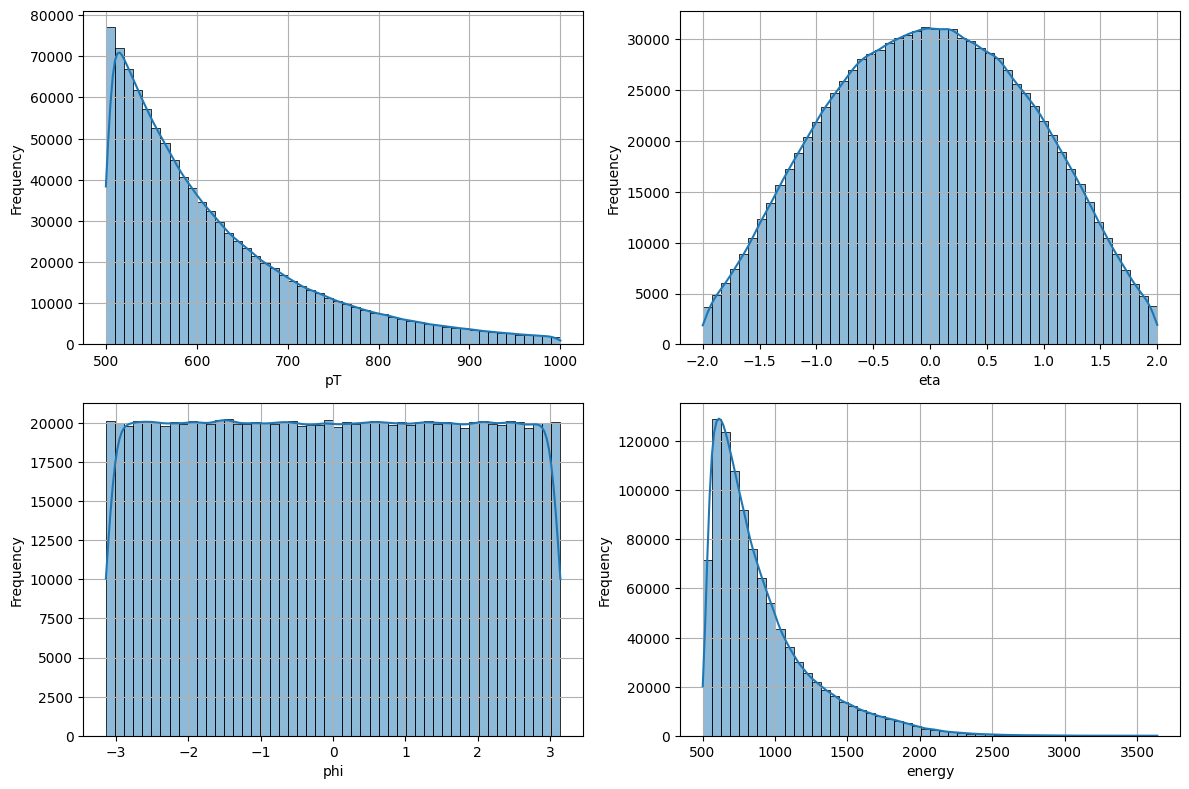

In [ ]:
# Visualize the distribution of each feature per jet
plot_feature_distribution(X_jets)

In [ ]:
# Normalize pT and energy
normalize = [True, False, False, True]
norm_dict = compute_norm_stats(X_particles)

pt_mean: 104.46350860595703, pt_std: 116.70646667480469
eta_mean: -0.0006092909025028348, eta_std: 0.9081049561500549
phi_mean: 8.528434409527108e-05, phi_std: 1.8136582374572754
E_mean: 149.4552001953125, E_std: 182.8554229736328


In [ ]:
# Randomly split the data into training, validation, and test sets
X_train, X_val, y_train, y_val = train_test_split(X_particles, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

# Datasets for self-supervised pre-training
train_dataset = JetClassDataset(X_train, y_train, normalize, norm_dict, mask_mode='biased')
val_dataset = JetClassDataset(X_val, y_val, normalize, norm_dict, mask_mode='biased')
test_dataset = JetClassDataset(X_test, y_test, normalize, norm_dict, mask_mode='first')

## Applying Gated Attention LorentzPart

In [ ]:
from typing import List, Tuple, Dict, Optional

import torch
from torch import nn, Tensor
from lgatr.interface import extract_vector
from lgatr.layers import EquiLinear

from src.models.classifier import ClassAttentionBlock, Classifier
from src.models.feedforward import Feedforward
from src.models.particle_transformer import ParticleAttentionBlock
from src.models.processor import InteractionEmbedding, ParticleProcessor
from src.configs import LorentzParTConfig
from lgatr.interface import extract_vector
from lgatr.layers import EquiLinear



class GatedParticleAttentionBlock(nn.Module):
    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 8,
        dropout: float = 0.1,
        expansion_factor: int = 4,
    ):
        super(GatedParticleAttentionBlock, self).__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads

        # Original layers from ParticleAttentionBlock
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.pmha = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

        # New Gating Layer
        self.gate = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.Sigmoid()
        )


        self.feedforward = Feedforward(
            embed_dim=embed_dim,
            expansion_factor=expansion_factor,
            dropout=dropout
        )

    def forward(self, x: Tensor, padding_mask: Tensor, U: Optional[Tensor] = None) -> Tensor:
        residual = x # The "identity" path

        # 1. Attention Branch
        attn_branch = self.layernorm1(x)
        attn_branch, _ = self.pmha(attn_branch, attn_branch, attn_branch,
                                   key_padding_mask=padding_mask,
                                   attn_mask=U)
        attn_branch = self.layernorm2(attn_branch)
        attn_branch = self.dropout(attn_branch)

        # 2. Compute Gate
        # We compute the gate based on the original input features
        g = self.gate(residual)

        # 3. Apply Gating (Mix Residual and Attention Branch)
        # Instead of a simple x += residual, we use the gate
        x = (1 - g) * residual + g * attn_branch

        # 4. Final Feedforward
        # The gating happens before the feedforward, mirroring the original structure
        x = self.feedforward(x)

        return x

class LorentzParTEncoder(nn.Module):
    def __init__(
        self,
        embed_dim: int = 128,
        num_heads: int = 8,
        num_layers: int = 8,
        in_s_channels: Optional[int] = None,
        out_s_channels: Optional[int] = None,
        dropout: float = 0.1,
        expansion_factor: int = 4,
        pair_embed_dims: List[int] = [64, 64, 64],
        attention_config: Dict = {} # Pass the attention dict here
    ):
        super(LorentzParTEncoder, self).__init__()
        self.equilinear = EquiLinear(
            in_mv_channels=1,
            out_mv_channels=1,
            in_s_channels=in_s_channels,
            out_s_channels=out_s_channels
        )
        self.proj = nn.Linear(16, embed_dim)
        self.interaction_embed = InteractionEmbedding(
            num_interaction_features=4,
            pair_embed_dims=pair_embed_dims + [num_heads]
        )

        # Check if gating is enabled in the config
        use_gating = attention_config.get('use_gating', False)

        self.encoder = nn.ModuleList([
            GatedParticleAttentionBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                dropout=dropout,
                expansion_factor=expansion_factor
            ) if use_gating else ParticleAttentionBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                dropout=dropout,
                expansion_factor=expansion_factor
            ) for _ in range(num_layers)
        ])

    def forward(self, x: Tensor, padding_mask: Tensor, U: Tensor) -> Tensor:
        B, N, F = x.shape
        U = self.interaction_embed(U)
        x = x.view(B, N, 1, F)
        x, _ = self.equilinear(x)
        x = x.view(B, N, 16)
        x = self.proj(x)

        for layer in self.encoder:
            x = layer(x, padding_mask, U)

        return x




class LorentzParT(nn.Module):
    def __init__(
        self,
        config: Optional[LorentzParTConfig] = None,
        max_num_particles: Optional[int] = None,
        num_particle_features: Optional[int] = None,
        num_classes: Optional[int] = None,
        embed_dim: Optional[int] = None,
        num_heads: Optional[int] = None,
        num_layers: Optional[int] = None,
        num_cls_layers: Optional[int] = None,
        num_mlp_layers: Optional[int] = None,
        hidden_dim: Optional[int] = None,
        hidden_mv_channels: Optional[int] = None,
        in_s_channels: Optional[int] = None,
        out_s_channels: Optional[int] = None,
        hidden_s_channels: Optional[int] = None,
        attention: Optional[Dict] = None,
        mlp: Optional[Dict] = None,
        reinsert_mv_channels: Optional[Tuple[int]] = None,
        reinsert_s_channels: Optional[Tuple[int]] = None,
        dropout: Optional[float] = None,
        expansion_factor: Optional[int] = None,
        pair_embed_dims: Optional[List[int]] = None,
        mask: Optional[bool] = None,
        weights: Optional[str] = None,
        inference: Optional[bool] = False
    ):
        super(LorentzParT, self).__init__()

        # Use config if provided, otherwise use defaults
        if config is not None:
            self.max_num_particles = max_num_particles if max_num_particles is not None else config.max_num_particles
            self.num_particle_features = num_particle_features if num_particle_features is not None else config.num_particle_features
            self.num_classes = num_classes if num_classes is not None else config.num_classes
            self.embed_dim = embed_dim if embed_dim is not None else config.embed_dim
            self.num_heads = num_heads if num_heads is not None else config.num_heads
            self.num_layers = num_layers if num_layers is not None else config.num_layers
            self.num_cls_layers = num_cls_layers if num_cls_layers is not None else config.num_cls_layers
            self.num_mlp_layers = num_mlp_layers if num_mlp_layers is not None else config.num_mlp_layers
            self.hidden_dim = hidden_dim if hidden_dim is not None else config.hidden_dim
            self.hidden_mv_channels = hidden_mv_channels if hidden_mv_channels is not None else config.hidden_mv_channels
            self.in_s_channels = in_s_channels if in_s_channels is not None else config.in_s_channels
            self.out_s_channels = out_s_channels if out_s_channels is not None else config.out_s_channels
            self.hidden_s_channels = hidden_s_channels if hidden_s_channels is not None else config.hidden_s_channels
            self.attention = attention if attention is not None else config.attention
            self.mlp = mlp if mlp is not None else config.mlp
            self.reinsert_mv_channels = reinsert_mv_channels if reinsert_mv_channels is not None else config.reinsert_mv_channels
            self.reinsert_s_channels = reinsert_s_channels if reinsert_s_channels is not None else config.reinsert_s_channels
            self.dropout = dropout if dropout is not None else config.dropout
            self.expansion_factor = expansion_factor if expansion_factor is not None else config.expansion_factor
            self.pair_embed_dims = pair_embed_dims if pair_embed_dims is not None else config.pair_embed_dims
            self.mask = mask if mask is not None else config.mask
            self.weights = weights if weights is not None else config.weights
            self.inference = inference if inference is not None else config.inference
        else:
            self.max_num_particles = max_num_particles if max_num_particles is not None else 128
            self.num_particle_features = num_particle_features if num_particle_features is not None else 4
            self.num_classes = num_classes if num_classes is not None else 10
            self.embed_dim = embed_dim if embed_dim is not None else 128
            self.num_heads = num_heads if num_heads is not None else 8
            self.num_layers = num_layers if num_layers is not None else 8
            self.num_cls_layers = num_cls_layers if num_cls_layers is not None else 2
            self.num_mlp_layers = num_mlp_layers if num_mlp_layers is not None else 0
            self.hidden_dim = hidden_dim if hidden_dim is not None else 256
            self.hidden_mv_channels = hidden_mv_channels if hidden_mv_channels is not None else 8
            self.in_s_channels = in_s_channels if in_s_channels is not None else None
            self.out_s_channels = out_s_channels if out_s_channels is not None else None
            self.hidden_s_channels = hidden_s_channels if hidden_s_channels is not None else 16
            self.attention = attention if attention is not None else {}
            self.mlp = mlp if mlp is not None else None
            self.reinsert_mv_channels = reinsert_mv_channels if reinsert_mv_channels is not None else None
            self.reinsert_s_channels = reinsert_s_channels if reinsert_s_channels is not None else None
            self.dropout = dropout if dropout is not None else 0.1
            self.expansion_factor = expansion_factor if expansion_factor is not None else 4
            self.pair_embed_dims = pair_embed_dims if pair_embed_dims is not None else [64, 64, 64]
            self.mask = mask if mask is not None else False
            self.weights = weights if weights is not None else None
            self.inference = inference if inference is not None else False

        # Initialize the class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.embed_dim), requires_grad=True)
        nn.init.normal_(self.cls_token, mean=0.0, std=1.0)

        self.processor = ParticleProcessor(to_multivector=True)

        # Updated Encoder with attention_config
        self.encoder = LorentzParTEncoder(
            embed_dim=self.embed_dim,
            num_heads=self.num_heads,
            num_layers=self.num_layers,
            in_s_channels=self.in_s_channels,
            out_s_channels=self.out_s_channels,
            dropout=self.dropout,
            expansion_factor=self.expansion_factor,
            pair_embed_dims=self.pair_embed_dims,
            attention_config=self.attention  # Pass dict containing 'use_gating'
        )

        # For self-supervised learning
        self.fc = nn.Linear(self.max_num_particles * self.embed_dim, 16)
        self.equilinear = EquiLinear(
            in_mv_channels=1,
            out_mv_channels=1,
            in_s_channels=self.in_s_channels,
            out_s_channels=self.out_s_channels
        )

        # For classification
        self.decoder = nn.ModuleList([
            ClassAttentionBlock(
                embed_dim=self.embed_dim,
                num_heads=self.num_heads,
                dropout=0.0,
                expansion_factor=self.expansion_factor
            ) for _ in range(self.num_cls_layers)
        ])
        self.layernorm = nn.LayerNorm(self.embed_dim)
        self.classifier = Classifier(
            num_classes=self.num_classes,
            input_dim=self.embed_dim,
            hidden_dim=self.hidden_dim,
            num_layers=self.num_mlp_layers,
            dropout=self.dropout,
        )
        self.act = nn.Softmax(dim=1) if self.inference else nn.Identity()

        # Load pretrained weights
        if self.weights is not None:
            state_dict = torch.load(self.weights)
            filtered_state = {
                k[len("encoder.") :]: v
                for k, v in state_dict.items()
                if k.startswith("encoder.")
            }
            self.encoder.load_state_dict(filtered_state, strict=False)

    def forward(self, x: Tensor, mask_idx: Optional[Tensor] = None) -> Tensor:
        B, N, F = x.shape  # (batch_size, max_num_particles, num_particle_features)

        # Ignore padding particles in query
        padding_mask = (x[..., 3] == 0).float()  # (B, N)

        # Set the masked indices to 0.0 so they are not ignored in MultiheadAttention()
        if mask_idx is not None:
            batch_indices = torch.arange(x.size(0), device=x.device)
            padding_mask[batch_indices, mask_idx] = 0.0

        # Process particles to get interaction embeddings and multivectors (if applicable)
        x, U = self.processor(x)

        # Pass through equilinear layer and particle attention blocks
        x = self.encoder(x, padding_mask, U)

        # Classification (no masking in this case)
        if not self.mask:
            x_cls = self.cls_token.expand(B, -1, -1)

            # Decoder with class attention blocks
            for layer in self.decoder:
                x_cls = layer(x, x_cls, padding_mask)

            # MLP head for classification
            x_cls = self.layernorm(x_cls).squeeze(1)
            x_cls = self.classifier(x_cls)
            output = self.act(x_cls)  # (B, num_classes)

            return output
        else:
            x = x.view(B, -1)  # (B, N * embed_dim)
            x = self.fc(x)  # (B, 16)
            x = x.view(B, 1, 1, 16)
            x, _ = self.equilinear(x)  # (B, 1, 1, 16)
            x = x.view(B, 16)
            x = extract_vector(x)  # (B, F)

            return x

#Gating Test

In [ ]:
# 1. Initialize your config with gating enabled
test_config = LorentzParTConfig(
    embed_dim=128,
    num_heads=8,
    num_layers=8,
    attention={'use_gating': True},
    mask=True
)

# 2. Instantiate the model
model = LorentzParT(config=test_config)

# 3. Verification checks
first_layer = model.encoder.encoder[0]
is_gated = isinstance(first_layer, GatedParticleAttentionBlock)

print(f"--- Gating Verification ---")
print(f"Encoder Layer 1 Type: {type(first_layer).__name__}")
print(f"Gating Active: {is_gated}")

if is_gated:
    print("Success: The model is now using Attention Gating!")
else:
    print("Error: The model is still using standard Attention Blocks.")

--- Gating Verification ---
Encoder Layer 1 Type: GatedParticleAttentionBlock
Gating Active: True
Success: The model is now using Attention Gating!


#Pre-Train

#Using Self Supervised Weights

In [ ]:
# Initialize configuration with Attention Gating enabled
#not changing name of ssl_model_config
ssl_model_config = LorentzParTConfig(
    embed_dim=128,
    num_heads=8,
    num_layers=8,
    hidden_mv_channels=8,
    attention={'use_gating': True}, # This is the trigger for your new code
    dropout=0.1,
    expansion_factor=4,
    max_num_particles=128,
    num_particle_features=4,
    pair_embed_dims=[64, 64, 64],
    mask=True # Set to True for Self-Supervised Learning / Masked Training
)

In [ ]:
# Create the model and move it to your device (GPU/CPU)
gatedmodel = LorentzParT(config=ssl_model_config)
gatedmodel.to(device)
gatedmodel

LorentzParT(
  (processor): ParticleProcessor()
  (encoder): LorentzParTEncoder(
    (equilinear): EquiLinear()
    (proj): Linear(in_features=16, out_features=128, bias=True)
    (interaction_embed): InteractionEmbedding(
      (embed): Sequential(
        (0): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): Conv1d(4, 64, kernel_size=(1,), stride=(1,))
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): GELU(approximate='none')
        (4): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): GELU(approximate='none')
        (7): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
        (8): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (9): GELU(approximate='none')
        (10): Conv1d(64, 8, kernel_size=(1,), stride=(1,))
        (11): BatchNorm1d(8, e

In [ ]:
num_params = sum(p.numel() for p in gatedmodel.parameters() if p.requires_grad)
num_params

2403216

In [ ]:
# Training configurations
gated_train_config = TrainConfig(
    batch_size=128,
    criterion={
        'name': 'conservation_loss',
        'kwargs': {
            'loss_coef': [0.25, 0.25, 0.25, 0.25],
            'reduction': 'mean'
        }
    },
    optimizer={
        'name': 'adamw',
        'kwargs': {
            'lr': 1e-4
        }
    },
    scheduler={
        'name': 'exponential_lr',
        'kwargs': {
            'gamma': 0.95
        }
    },
    callbacks=[{
        'name': 'early_stopping',
        'kwargs': {
            'monitor': 'val_loss',
            'mode': 'min',
            'patience': 5
        }
    }],
    num_epochs=20,#20
    start_epoch=0,
    logging_dir=str(LOG_DIR),
    logging_steps=1000,
    progress_bar=True,
    save_best=True,
    save_ckpt=True,
    save_fig=False,
    device='cuda',
    num_workers=0,
    pin_memory=True
)

In [ ]:
# Initialize the trainer
trainer = MaskedModelTrainer(
    model=gatedmodel,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    device=device,
    config=gated_train_config
)

In [ ]:
# Train the model
gated_history, gatedmodel = trainer.train()

Training:   0%|          | 0/125000 [00:00<?, ?it/s]

step: 1000/125000 | pT_loss: 0.4168 | eta_loss: 0.2395 | phi_loss: 0.0741 | energy_loss: 0.4237 | total_train_loss: 0.2885
step: 2000/125000 | pT_loss: 0.3380 | eta_loss: 0.2155 | phi_loss: 0.0569 | energy_loss: 0.3510 | total_train_loss: 0.2404
step: 3000/125000 | pT_loss: 0.2931 | eta_loss: 0.2018 | phi_loss: 0.0490 | energy_loss: 0.3078 | total_train_loss: 0.2129
step: 4000/125000 | pT_loss: 0.2664 | eta_loss: 0.1935 | phi_loss: 0.0445 | energy_loss: 0.2824 | total_train_loss: 0.1967
step: 5000/125000 | pT_loss: 0.2478 | eta_loss: 0.1877 | phi_loss: 0.0415 | energy_loss: 0.2645 | total_train_loss: 0.1854
step: 6000/125000 | pT_loss: 0.2345 | eta_loss: 0.1837 | phi_loss: 0.0396 | energy_loss: 0.2509 | total_train_loss: 0.1772
epoch: 1/20 | pT_loss: 0.1522 | eta_loss: 0.1862 | phi_loss: 0.0266 | energy_loss: 0.1632 | total_val_loss: 0.1320
step: 7000/125000 | pT_loss: 0.1598 | eta_loss: 0.1631 | phi_loss: 0.0279 | energy_loss: 0.1787 | total_train_loss: 0.1323
step: 8000/125000 | pT_l

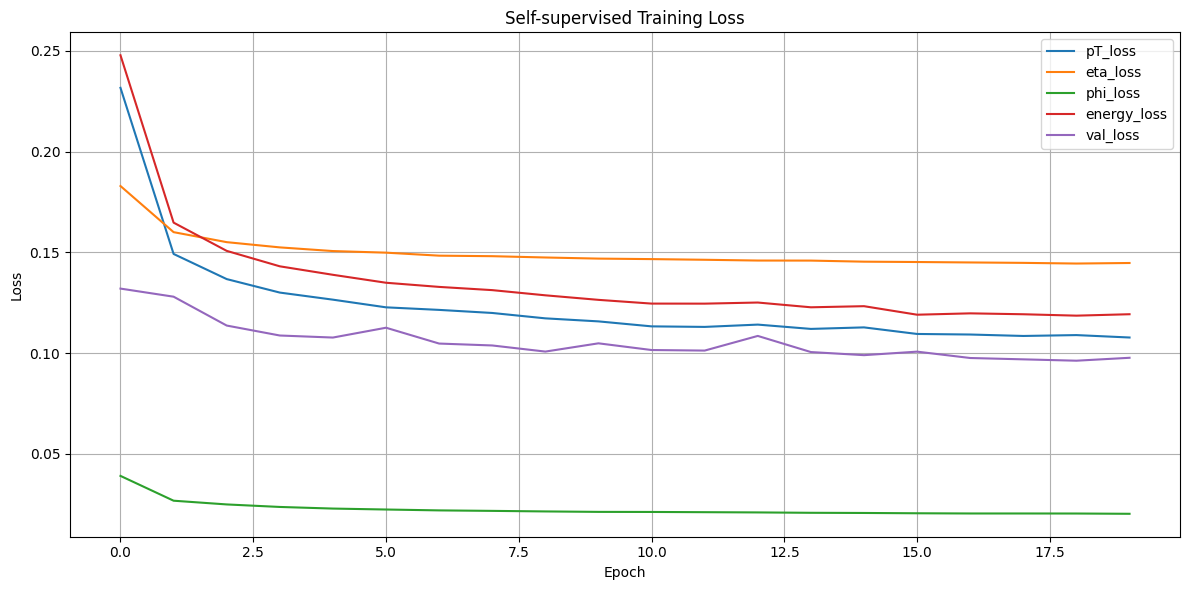

In [ ]:
# Visualize the self-supervised training history
plt.figure(figsize=(12, 6))
plt.plot(gated_history['pT_loss'], label="pT_loss")
plt.plot(gated_history['eta_loss'], label="eta_loss")
plt.plot(gated_history['phi_loss'], label="phi_loss")
plt.plot(gated_history['energy_loss'], label="energy_loss")
plt.plot(gated_history['val_loss'], label="val_loss")
plt.title("Self-supervised Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# --- Save for the Gated Architecture ---

gated_pt_path = LOG_DIR / gatedmodel.__class__.__name__ / 'best' / 'gated_lorentz_part_v1.pt'

# Ensure the directory exists
gated_pt_path.parent.mkdir(parents=True, exist_ok=True)

# Save the full state_dict (Transformer + Trained Gates)
torch.save(gatedmodel.state_dict(), gated_pt_path)

print(f"Gated model saved to: {gated_pt_path}")

Gated model saved to: /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen/logs/LorentzParT/best/gated_lorentz_part_v1.pt


In [ ]:
trainer.load_best_model(gated_pt_path)

In [ ]:
import torch
import os


# 2. Check if the file exists and show its size
if gated_pt_path.exists():
    file_size_mb = os.path.getsize(gated_pt_path) / (1024 * 1024)
    print(f" File found at: {gated_pt_path}")
    print(f" File size: {file_size_mb:.2f} MB")

    # 3. Load the state_dict to inspect contents
    print("\nInspecting state_dict keys...")
    checkpoint = torch.load(gated_pt_path, map_location='cpu')

    # 4. Specifically look for the new 'gate' parameters
    gate_keys = [k for k in checkpoint.keys() if 'gate' in k]

    if gate_keys:
        print(f" Found {len(gate_keys)} gating-related parameters.")
        print("Example keys found:")
        for key in gate_keys[:5]:  # Show the first 5 gate keys
            print(f" - {key}")
    else:
        print("No 'gate' parameters found. The model might have saved in the old format.")

    # Optional: Show total number of saved parameter tensors
    print(f"\nTotal parameter tensors saved: {len(checkpoint.keys())}")

else:
    print(f"Error at {gated_pt_path}")

 File found at: /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen/logs/LorentzParT/best/gated_lorentz_part_v1.pt
 File size: 9.25 MB

Inspecting state_dict keys...
 Found 16 gating-related parameters.
Example keys found:
 - encoder.encoder.0.gate.0.weight
 - encoder.encoder.0.gate.0.bias
 - encoder.encoder.1.gate.0.weight
 - encoder.encoder.1.gate.0.bias
 - encoder.encoder.2.gate.0.weight

Total parameter tensors saved: 222


test_loss: 1.3291 | pT_loss: 1.7469 | eta_loss: 0.7920 | phi_loss: 0.9751 | energy_loss: 1.8024


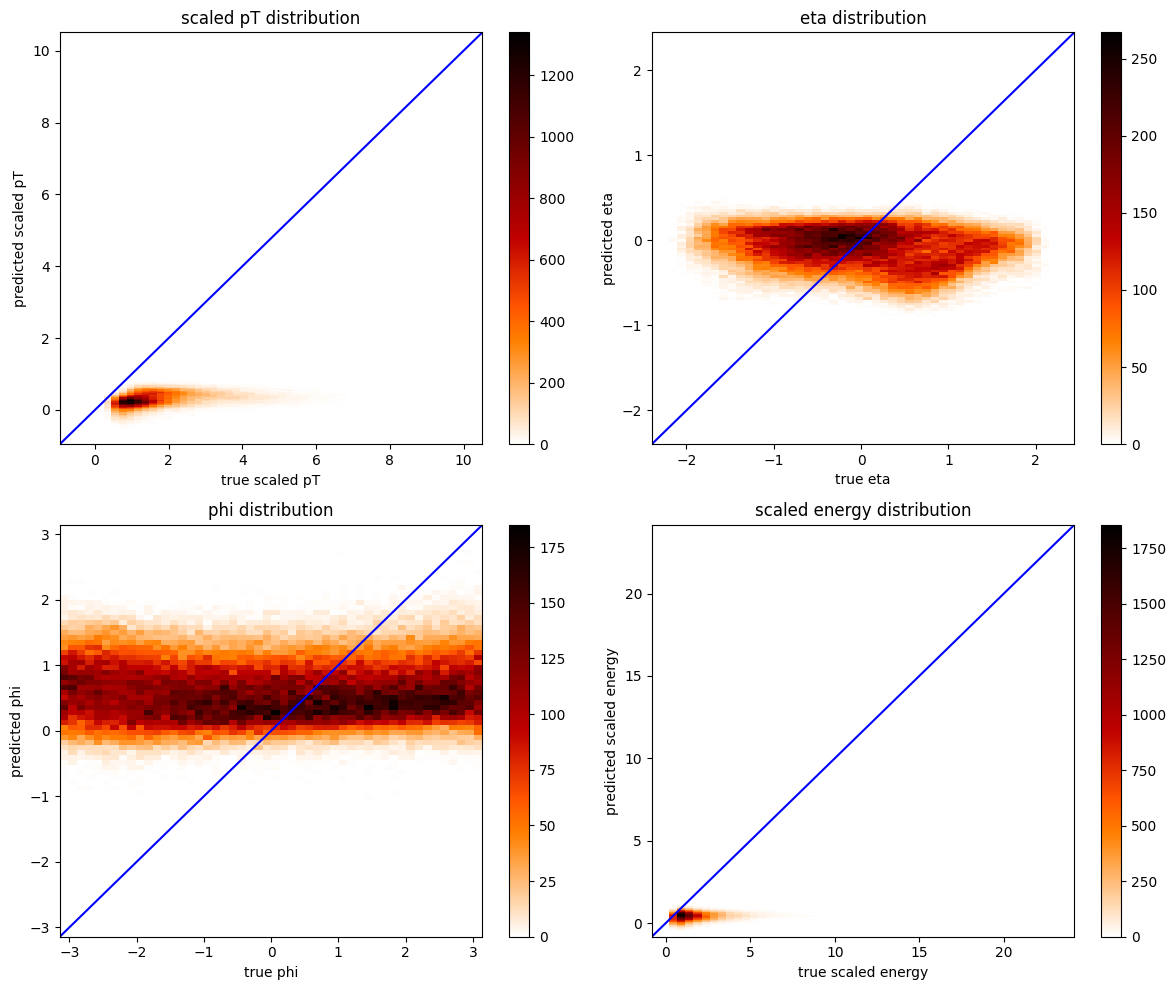

In [ ]:
# Evaluate the model on the test set
test_loss, test_metric, y_true, y_pred = trainer.evaluate(plot=plot_particle_reconstruction)